Analysation of the data coming from the simulator.

In [8]:
import numpy as np
import xarray as xr
import yaml
import concurrent.futures
from plotter import plotter
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from wireless_channel.subTHz_channel import Channel
from wireless_channel.waveforms import Waveform
from sub_THz_stripe.central_unit.central_unit import CentralUnit
from sub_THz_stripe.radio_unit.radio_unit import RadioUnit
from sub_THz_stripe.amplifier.amplifier import Amplifier
from sub_THz_stripe.combiner.combiner import Combiner
from sub_THz_stripe.coupler.coupler import Coupler
from sub_THz_stripe.phase_shifter.phase_shifter import PhaseShifter
from sub_THz_stripe.splitter.splitter import Splitter

In [9]:
# Which simulation environment to plot the channels for.
environment = "office_space_inline"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

stripe_config = config["stripe_config"]

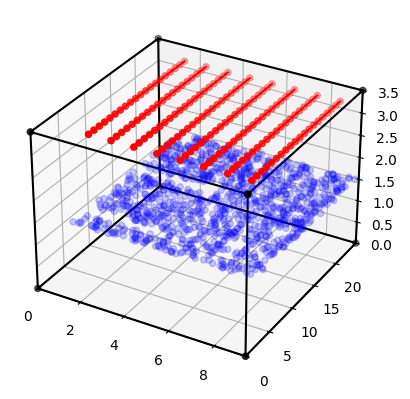

In [10]:
# Plot the room with the strip in it.
plotter.plot_room(config)

In [11]:
# Read out the Waveform config file.
config_file = "environments/waveform_config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    waveform_config = yaml.safe_load(file)

# Construct the waveform class based on the loaded configuration.
freq_band_config = config["sub_thz"]
wf = Waveform.from_config(waveform_config, freq_band_config)

In [12]:
# Generate an CP-OFDM waveform in the time domain.
bits = wf.generate_bits()
qam = wf.qam_modulate()
ofdm_time = wf.ofdm_modulate()  # shape: nr_ofdm_symb x (fftsize + cp length)

# Thomas F. manier
pavg = np.mean(np.abs(ofdm_time) ** 2)
alpha = np.sqrt(1 / pavg)
ofdm_time = ofdm_time * alpha
pavg = 10 * np.log10(np.mean(np.abs(ofdm_time) ** 2) / 1e-3)

In [13]:
# The UE has the same hardware as a central unit.
ue = CentralUnit()  # todo are these configs loadable?
ofdm_time_after_ue = ue.run(ofdm_time)  # shape: nr_ofdm_symbols x (fft_size + cp length)

# A single radio unit is used to represent the transmit stage of the ue. The UE position does not influence the
# transmission so we can set it arbitrarily.
amp = Amplifier(bw=config["sub_thz"]["bw"], max_out_amp=33)
coup = Coupler(wf=wf)
split = Splitter(config["antenna"]["N_antennas"])
comb = Combiner()
ps = PhaseShifter(num_shifters=config["antenna"]["N_antennas"], resolution=4, in_degrees=True)
ue_ru = RadioUnit(x=0, y=0, z=0, boost_amp=amp, antenna_amp=amp, coup_in=coup, coup_out=coup, splitter=split, combiner=comb, pshift=ps)

In [14]:
ue_ds = xr.load_dataset(f"wireless_channel/sionna_dataset/{environment}/ue_locations/ue_locations.nc")

def plot_channel(ue_pos, wf, ofdm_time):
    for ue_beam in range(1):
        ue_shift = ue_ru.phase_shifter.get_phases(ue_beam)
        ue_shift = [0,0,0,0]
        iq_data_tx, imdata = ue_ru.transmit(ofdm_time, ue_shift)

        channel = Channel.from_sionna(ue_pos, environment)
        # Transmit the data over the channel and get the data at all the radio units.
        iq_data_rx = channel.transmit_ul(iq_data_tx, wf)

        # Make a plot for every UE. The plot is a heatmap with the data for every stripe on the y-axis and the data for every
        # RU on the x-axis.
        fig, ax = plt.subplots()
        data = np.zeros((iq_data_rx.shape[0], iq_data_rx.shape[1]))
        for stripe_idx, stripe_data in enumerate(iq_data_rx):
            # Now iterate over all the data from the different RUs and calculate the pavg.
            for ru_idx, ru_data in enumerate(stripe_data):
                pavg = np.mean(np.abs(ru_data[0]) ** 2)
                pavg = 10 * np.log10(pavg / 1e-3)

                data[stripe_idx, ru_idx] = pavg
            
        im = ax.imshow(data)
        startx = stripe_config["stripe_start_pos"][0]
        starty = stripe_config["stripe_start_pos"][1]
        circle = Circle(((ue_pos["y"] - starty), (ue_pos["x"] - startx)), radius=0.2, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(circle)

        # Create colorbar
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel("Average power", rotation=-90, va="bottom")

        ax.set_ylabel("Stripe")
        ax.set_xlabel("Radio Unit")
        x = round(ue_pos["x"])
        y = round(ue_pos["y"])
        z = round(ue_pos["z"])
        ax.set_title(f"UE: x{x} y{y} z{z}, beam: {ue_beam}")
        fig.savefig(f"examples/channels/channel_x{x}_y{y}_z{z}_b{ue_beam}.pdf")
        fig.show()

# Loop over all the UE positions and perform an exhaustive search.
workers = []
with concurrent.futures.ProcessPoolExecutor(max_workers=32) as executor:
    for ue_pos in config["ue_positions"][:6]:
        worker = executor.submit(plot_channel, ue_pos, wf, ofdm_time_after_ue)
        workers.append(worker)
    
    concurrent.futures.wait(workers)